In [1]:
import pandas as pd
df = pd.read_csv('Car_sales (1).csv')
df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [2]:
top_models = df.sort_values('Sales_in_thousands', ascending=False).head(10)
top_models[['Manufacturer', 'Model', 'Sales_in_thousands']]

,Manufacturer,Model,Sales_in_thousands
56,Ford,F-Series,540.561
52,Ford,Explorer,276.747
137,Toyota,Camry,247.994
49,Ford,Taurus,245.815
58,Honda,Accord,230.902
40,Dodge,Ram Pickup,227.061
55,Ford,Ranger,220.650
57,Honda,Civic,199.685
45,Dodge,Caravan,181.749
50,Ford,Focus,175.670


Matplotlib is building the font cache; this may take a moment.


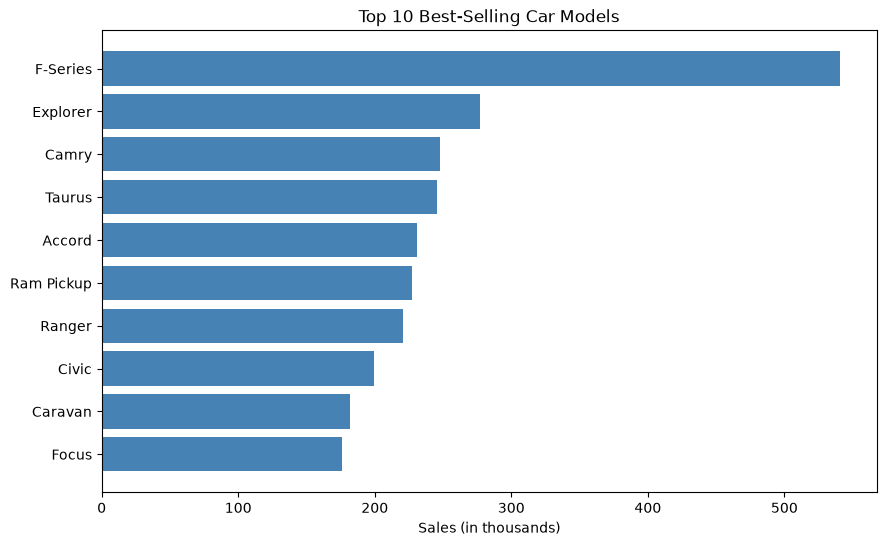

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_models['Model'], top_models['Sales_in_thousands'], color='steelblue')
plt.xlabel('Sales (in thousands)')
plt.title('Top 10 Best-Selling Car Models')
plt.gca().invert_yaxis()  # puts the highest seller at the top
plt.show()

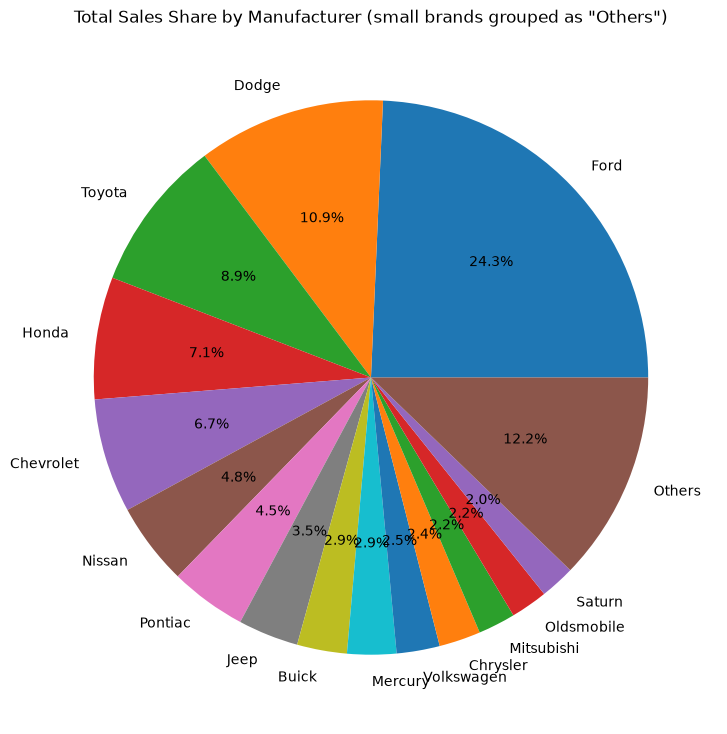

In [5]:
manufacturer_sales = df.groupby('Manufacturer')['Sales_in_thousands'].sum().sort_values(ascending=False)

threshold = 0.02 * manufacturer_sales.sum()  # anything under 2% of total sales
top = manufacturer_sales[manufacturer_sales >= threshold]
others = pd.Series({'Others': manufacturer_sales[manufacturer_sales < threshold].sum()})
cleaned = pd.concat([top, others])

plt.figure(figsize=(9,9))
plt.pie(cleaned, labels=cleaned.index, autopct='%1.1f%%')
plt.title('Total Sales Share by Manufacturer (small brands grouped as "Others")')
plt.show()

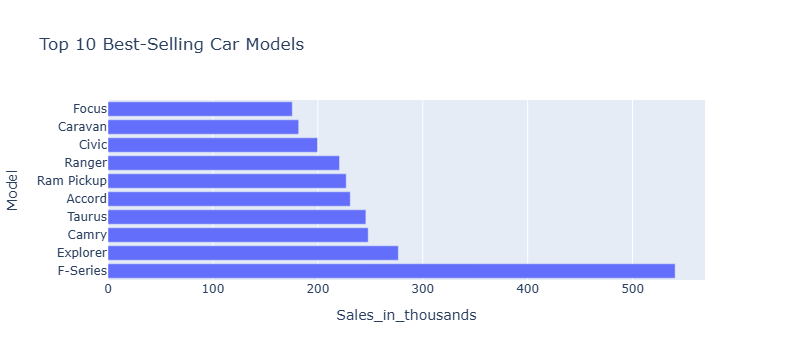

In [6]:
import plotly.express as px

fig = px.bar(top_models, x='Sales_in_thousands', y='Model', orientation='h',
             title='Top 10 Best-Selling Car Models')
fig.show()

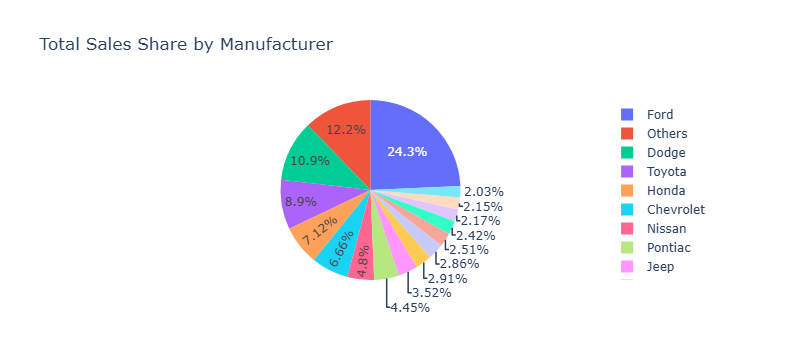

In [7]:
fig2 = px.pie(cleaned, names=cleaned.index, values=cleaned.values,
              title='Total Sales Share by Manufacturer')
fig2.show()

## Key Insights

- **Ford dominates the market**, driven heavily by the F-Series pickup, which outsells the next closest model (Explorer) by nearly 2x.
- The **top 5 manufacturers** (Ford, Toyota, Honda, Chevrolet, Nissan) account for over half of total industry sales, while dozens of smaller brands split the remaining share.
- **Trucks and SUVs** (F-Series, Ram Pickup, Explorer, Ranger) sit alongside traditional sedans (Camry, Accord, Taurus) in the top 10 — showing strong demand for both utility vehicles and passenger cars.
- The market is **top-heavy**: a handful of models drive a disproportionate share of sales, while the "Others" segment (many small manufacturers) still adds up to over 12% combined.